# 0. Setup work

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text, URL

In [3]:
plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

In [4]:
DB_USER     = os.getenv("MYSQL_USER")
DB_PASSWORD = os.getenv("MYSQL_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = int(os.getenv("DB_PORT"))
DB_NAME     = os.getenv("MYSQL_DATABASE")
 
engine = create_engine(
    URL.create(
        "mysql",
        DB_USER,
        DB_PASSWORD,
        DB_HOST,
        DB_PORT,
        DB_NAME
    ),
    pool_pre_ping=True,
)
 
# quick connectivity test
with engine.connect() as conn:
    conn.execute(text("SELECT 1"))
print("connected")


connected


## 1 · Dimension snapshots
Quick look at all current records in both SCD-2 dimensions.


In [4]:
sql_dim = """
SELECT
    dp.parameter_key,
    dp.parameter_code,
    dp.parameter_name,
    dp.local_name,
    du.unit_symbol,
    dp.threshold_limit,
    dp.valid_from,
    dp.valid_to,
    dp.is_current
FROM dim_parameters dp
LEFT JOIN dim_units du ON dp.unit_key = du.unit_key
ORDER BY dp.parameter_code, dp.valid_from
"""
df_params = pd.read_sql(sql_dim, engine)
print(f"dim_parameters rows: {len(df_params)}  "
      f"| current: {df_params['is_current'].sum()}")
df_params.head(30)


dim_parameters rows: 22  | current: 22


,parameter_key,parameter_code,parameter_name,local_name,unit_symbol,threshold_limit,valid_from,valid_to,is_current
0,5,BME280HUMIDITY,Humidity,Вологість,%,0.0,2026-04-29 11:48:18,None,1
1,6,BME280PRESSURE,Pressure,Атмосферний тиск,Pa,0.0,2026-04-29 11:48:18,None,1
2,4,BME280TEMPERATURE,Temperature,Температура,°C,0.0,2026-04-29 11:48:18,None,1
3,19,CO,CO,Монооксид вуглецю,ppm,0.0,2026-04-29 11:48:18,None,1
4,3,CO2,CO₂,CO₂,ppm,0.0,2026-04-29 11:48:18,None,1
5,16,HCHO,VOC (H₂CO),ЛОС (Формальдегід),mg/m³,0.0,2026-04-29 11:48:18,None,1
6,11,Humidity,Humidity,Вологість,%,0.0,2026-04-29 11:48:18,None,1
7,22,NH₃,NH₃,Аміак,ppm,0.0,2026-04-29 11:48:18,None,1
8,18,NO2,NO₂,Діоксид азоту,ppm,0.0,2026-04-29 11:48:18,None,1
9,17,O3,O₃,O₃,ppm,0.0,2026-04-29 11:48:18,None,1


In [5]:
sql_stations = """
SELECT
    station_key, station_id, station_name,
    latitude, longitude, timezone_offset,
    valid_from, valid_to, is_current
FROM dim_stations
ORDER BY station_id, valid_from
"""
df_stations = pd.read_sql(sql_stations, engine)
print(f"dim_stations rows: {len(df_stations)}  "
      f"| current: {df_stations['is_current'].sum()}")
df_stations.head(20)


dim_stations rows: 32  | current: 32


,station_key,station_id,station_name,latitude,longitude,timezone_offset,valid_from,valid_to,is_current
0,31,65,vinnytsia-65,49.1743,28.5305,0,2026-04-29 11:48:19,None,1
1,22,90,vinnytsia-90,49.2177,28.4498,0,2026-04-29 11:48:19,None,1
2,23,92,vinnytsia-92,49.2277,28.4448,0,2026-04-29 11:48:19,None,1
3,28,95,vinnytsia-95,49.2277,28.4448,0,2026-04-29 11:48:19,None,1
4,29,174,vinnytsia-174,49.2280,28.4454,0,2026-04-29 11:48:19,None,1
5,16,246,vinnytsia-246,49.2235,28.4009,0,2026-04-29 11:48:19,None,1
6,17,256,vinnytsia-256,49.2088,28.5285,0,2026-04-29 11:48:19,None,1
7,18,271,vinnytsia-271,49.2369,28.5133,0,2026-04-29 11:48:19,None,1
8,19,274,vinnytsia-274,49.2248,28.4249,0,2026-04-29 11:48:19,None,1
9,20,281,vinnytsia-281,49.2419,28.4620,0,2026-04-29 11:48:19,None,1


### 1.1 · Known pollutant mapping
Cross-reference the parameter codes actually present in the DB against the
expected catalogue.  Rows that appear only on one side need investigation.


In [6]:
CATALOGUE = {
    "SDSP2":              "PM2.5",
    "SDSP1":              "PM10",
    "CO2":                "CO₂",
    "BME280TEMPERATURE":  "Temperature",
    "BME280HUMIDITY":     "Humidity",
    "BME280PRESSURE":     "Pressure",
    "PM1.0":              "PM1.0",
    "PM2.5":              "PM2.5",
    "PM10":               "PM10",
    "Temperature":        "Temperature",
    "Humidity":           "Humidity",
    "PMSP0":              "PM1.0",
    "PMSP2":              "PM2.5",
    "PMSP1":              "PM10",
    "Pressure":           "Pressure",
    "HCHO":               "VOC (H₂CO)",
    "O3":                 "O₃",
    "NO2":                "NO₂",
    "CO":                 "CO",
    "VOC":                "VOC (H₂CO)",
    "Radiation":          "RAD",
    "NH₃":                "NH₃",
}
 
current_codes = set(df_params.loc[df_params["is_current"] == 1, "parameter_code"])
catalogue_codes = set(CATALOGUE.keys())
 
print("In DB but NOT in catalogue:", current_codes - catalogue_codes or "none")
print("In catalogue but NOT in DB:", catalogue_codes - current_codes or "none")

In DB but NOT in catalogue: none
In catalogue but NOT in DB: none


## 2 · Load fact data
Start with a focused slice — one or two parameter codes, all current stations, a date window.  Scale up once the pipeline is validated.


In [7]:
PARAM_CODES = ["PM2.5", "PMSP2", "SDSP2"]   # logical PM2.5 family
DATE_FROM   = "2023-01-01"
DATE_TO     = "2025-01-01"          # set None to remove upper bound
CHUNKSIZE   = 200_000

In [8]:
date_filter = "AND fm.measurement_timestamp >= :date_from"
params      = {"date_from": DATE_FROM}
if DATE_TO:
    date_filter += " AND fm.measurement_timestamp < :date_to"
    params["date_to"] = DATE_TO
 
code_placeholders = ", ".join(f":c{i}" for i in range(len(PARAM_CODES)))
for i, c in enumerate(PARAM_CODES):
    params[f"c{i}"] = c
 
sql_fact = f"""
SELECT
    fm.measurement_id,
    fm.measurement_timestamp,
    fm.station_key,
    fm.parameter_key,
    fm.value,
    fm.quality_ratio,
    fm.pollution_level,
    fm.offset_minutes,
    ds.station_id,
    ds.station_name,
    dp.parameter_code,
    dp.parameter_name
FROM fact_measurements fm
JOIN dim_stations   ds ON fm.station_key   = ds.station_key  AND ds.is_current = 1
JOIN dim_parameters dp ON fm.parameter_key = dp.parameter_key AND dp.is_current = 1
WHERE dp.parameter_code IN ({code_placeholders})
  {date_filter}
ORDER BY fm.measurement_timestamp
"""
 
chunks = []
for chunk in pd.read_sql(text(sql_fact), engine, params=params, chunksize=CHUNKSIZE):
    # downcast immediately to save memory
    chunk["station_key"]   = chunk["station_key"].astype("int32")
    chunk["parameter_key"] = chunk["parameter_key"].astype("int16")
    chunk["value"]         = chunk["value"].astype("float32")
    chunk["quality_ratio"] = chunk["quality_ratio"].astype("float32")
    chunk["pollution_level"] = pd.to_numeric(chunk["pollution_level"],
                                             errors="coerce").astype("Int8")
    chunk["measurement_timestamp"] = pd.to_datetime(chunk["measurement_timestamp"])
    chunks.append(chunk)
 
df = pd.concat(chunks, ignore_index=True)
print(f"Loaded {len(df):,} rows  |  memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()


Loaded 625,753 rows  |  memory: 67.5 MB


,measurement_id,measurement_timestamp,station_key,parameter_key,value,quality_ratio,pollution_level,offset_minutes,station_id,station_name,parameter_code,parameter_name
0,260281,2023-01-05 11:29:02,3,1,7.87,1.0,1,0,790,станція Вишенька,SDSP2,PM2.5
1,260275,2023-01-05 11:29:24,2,1,7.94,1.0,1,0,774,Станція замостя,SDSP2,PM2.5
2,260288,2023-01-05 11:29:43,6,8,15.00,1.0,2,0,1315,Vinnytsia National Technical University,PM2.5,PM2.5
3,260302,2023-01-05 11:30:01,4,8,9.02,1.0,1,0,1769,Lun-315,PM2.5,PM2.5
4,260333,2023-01-05 11:44:01,4,8,8.69,1.0,1,0,1769,Lun-315,PM2.5,PM2.5


In [6]:
import pandas as pd
from sqlalchemy import create_engine, text
from datetime import datetime
from IPython.display import display

# ── Config ────────────────────────────────────────────────────────────────────
ENGINE    = engine
DATE_FROM = datetime(2024, 1, 1)
DATE_TO   = None  # or datetime(2024, 12, 31)

# ── Build params & date filter ────────────────────────────────────────────────
params = {"date_from": DATE_FROM}

date_filter = "AND f.measurement_timestamp >= :date_from"
if DATE_TO:
    date_filter += " AND f.measurement_timestamp < :date_to"
    params["date_to"] = DATE_TO

# ── MySQL 8.0 compatible percentiles via PERCENT_RANK ─────────────────────────
DIAGNOSTIC_SQL = f"""
WITH ranked AS (
    SELECT
        p.parameter_code,
        p.parameter_name,
        u.unit_symbol,
        p.physical_min,
        p.physical_max,
        f.value,
        PERCENT_RANK() OVER (
            PARTITION BY p.parameter_code
            ORDER BY f.value
        ) AS pct_rank
    FROM dim_parameters p
    JOIN fact_measurements f ON f.parameter_key = p.parameter_key
    LEFT JOIN dim_units u     ON u.unit_key      = p.unit_key
    WHERE p.is_current = 1
      AND f.value IS NOT NULL
      {date_filter}
)
SELECT
    parameter_code,
    parameter_name,
    unit_symbol,
    physical_min,
    physical_max,

    COUNT(value)                                                    AS reading_count,
    MIN(value)                                                      AS observed_min,
    MAX(value)                                                      AS observed_max,
    AVG(value)                                                      AS observed_mean,

    MAX(CASE WHEN pct_rank <= 0.010 THEN value END)                 AS p01,
    MAX(CASE WHEN pct_rank <= 0.050 THEN value END)                 AS p05,
    MAX(CASE WHEN pct_rank <= 0.500 THEN value END)                 AS p50,
    MAX(CASE WHEN pct_rank <= 0.950 THEN value END)                 AS p95,
    MAX(CASE WHEN pct_rank <= 0.990 THEN value END)                 AS p99,
    MAX(CASE WHEN pct_rank <= 0.999 THEN value END)                 AS p999,

    SUM(CASE WHEN value < physical_min THEN 1 ELSE 0 END)          AS below_physical_min,
    SUM(CASE WHEN value > physical_max THEN 1 ELSE 0 END)          AS above_physical_max,

    SUM(CASE WHEN value > 500  THEN 1 ELSE 0 END)                  AS above_500,
    SUM(CASE WHEN value > 1000 THEN 1 ELSE 0 END)                  AS above_1000,
    SUM(CASE WHEN value > 2000 THEN 1 ELSE 0 END)                  AS above_2000

FROM ranked
GROUP BY
    parameter_code,
    parameter_name,
    unit_symbol,
    physical_min,
    physical_max
ORDER BY
    parameter_code
"""

# ── Run ───────────────────────────────────────────────────────────────────────
date_to_str = DATE_TO.strftime("%Y-%m-%d") if DATE_TO else "now"
print(f"Diagnostic range: {DATE_FROM.strftime('%Y-%m-%d')} → {date_to_str}")

with ENGINE.connect() as conn:
    df = pd.read_sql(text(DIAGNOSTIC_SQL), conn, params=params)

# ── Tidy up types ─────────────────────────────────────────────────────────────
int_cols   = ["reading_count", "below_physical_min", "above_physical_max",
              "above_500", "above_1000", "above_2000"]
float_cols = ["observed_min", "observed_max", "observed_mean",
              "physical_min", "physical_max",
              "p01", "p05", "p50", "p95", "p99", "p999"]

df[int_cols]   = df[int_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
df[float_cols] = df[float_cols].apply(pd.to_numeric, errors="coerce").round(2)

# ── Display ───────────────────────────────────────────────────────────────────
def highlight_suspicious(row):
    """Red if max is way above p99.9; yellow if anything exceeds physical_max."""
    styles = [""] * len(row)
    col = list(row.index)

    above_max = row["above_physical_max"] > 0
    spike     = pd.notna(row["p999"]) and pd.notna(row["observed_max"]) \
                and row["observed_max"] > row["p999"] * 5

    if spike:
        styles[col.index("observed_max")] = "background-color: #f8d7da; color: #721c24"
    if above_max:
        styles[col.index("above_physical_max")] = "background-color: #fff3cd; color: #856404"

    return styles

styled = (
    df.style
    .apply(highlight_suspicious, axis=1)
    .format({
        "reading_count":       "{:,}",
        "below_physical_min":  "{:,}",
        "above_physical_max":  "{:,}",
        "above_500":           "{:,}",
        "above_1000":          "{:,}",
        "above_2000":          "{:,}",
        "observed_min":        "{:.2f}",
        "observed_max":        "{:.2f}",
        "observed_mean":       "{:.2f}",
        "physical_min":        "{:.2f}",
        "physical_max":        "{:.2f}",
        "p01":                 "{:.2f}",
        "p05":                 "{:.2f}",
        "p50":                 "{:.2f}",
        "p95":                 "{:.2f}",
        "p99":                 "{:.2f}",
        "p999":                "{:.2f}",
    }, na_rep="—")
    .set_caption(f"Parameter diagnostics — {DATE_FROM.strftime('%Y-%m-%d')} → {date_to_str}")
    .set_table_styles([
        {"selector": "thead th",
         "props": [("background-color", "#2c3e50"), ("color", "white"),
                   ("font-size", "11px"), ("text-align", "center")]},
        {"selector": "tbody td",
         "props": [("font-size", "11px"), ("text-align", "right")]},
        {"selector": "tbody td:first-child, tbody td:nth-child(2), tbody td:nth-child(3)",
         "props": [("text-align", "left")]},
        {"selector": "caption",
         "props": [("font-size", "13px"), ("font-weight", "bold"),
                   ("margin-bottom", "8px")]},
    ])
)

display(styled)
print(f"\n{len(df)} parameters analysed  |  {df['reading_count'].sum():,} total readings")

Diagnostic range: 2024-01-01 → now


,parameter_code,parameter_name,unit_symbol,physical_min,physical_max,reading_count,observed_min,observed_max,observed_mean,p01,p05,p50,p95,p99,p999,below_physical_min,above_physical_max,above_500,above_1000,above_2000
0,CO,CO,ppm,0.00,50.00,"125,768",0.00,6.23,1.31,0.00,0.00,1.08,2.97,4.15,4.74,0,0,0,0,0
1,Humidity,Humidity,%,0.00,100.00,"809,302",2.25,100.00,67.46,23.74,33.33,71.09,98.57,100.00,100.00,0,0,0,0,0
2,NH₃,NH₃,ppm,0.00,500.00,"72,220",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0
3,NO2,NO₂,ppm,0.00,1000.00,"95,923",0.01,74.32,7.62,0.02,0.03,0.04,36.26,43.91,55.55,0,0,0,0,0
4,O3,O₃,ppm,0.00,500.00,"28,967",0.01,20.22,0.56,0.02,0.02,0.02,0.07,20.00,20.00,0,0,0,0,0
5,PM10,PM10,µg/m³,0.00,2000.00,"1,050,837",0.00,3333.66,32.46,0.82,1.90,9.48,37.34,309.51,1999.90,0,237,"10,300","10,067",237
6,PM2.5,PM2.5,µg/m³,0.00,1500.00,"786,043",0.00,3333.66,21.26,0.65,1.29,5.40,27.85,999.90,999.90,0,122,"9,964",123,119
7,Pressure,Pressure,Pa,850.00,1100.00,"723,301",90599.10,108508.00,98657.98,96690.53,97279.93,98635.56,100136.74,100845.19,101747.04,0,"723,301","723,301","723,301","723,301"
8,Radiation,RAD,uR/h,—,—,"371,180",0.00,133.89,13.12,9.73,10.34,13.47,15.63,16.55,17.44,0,0,0,0,0
9,Temperature,Temperature,°C,-40.00,60.00,"1,207,011",-27.34,49.64,12.39,-9.21,-2.43,11.75,29.12,35.17,39.73,0,0,0,0,0



11 parameters analysed  |  5,348,849 total readings


## 3 · Missing data

### 3.1 Overall missing data

pollution_level    0.912545
quality_ratio      0.280363
value              0.000000


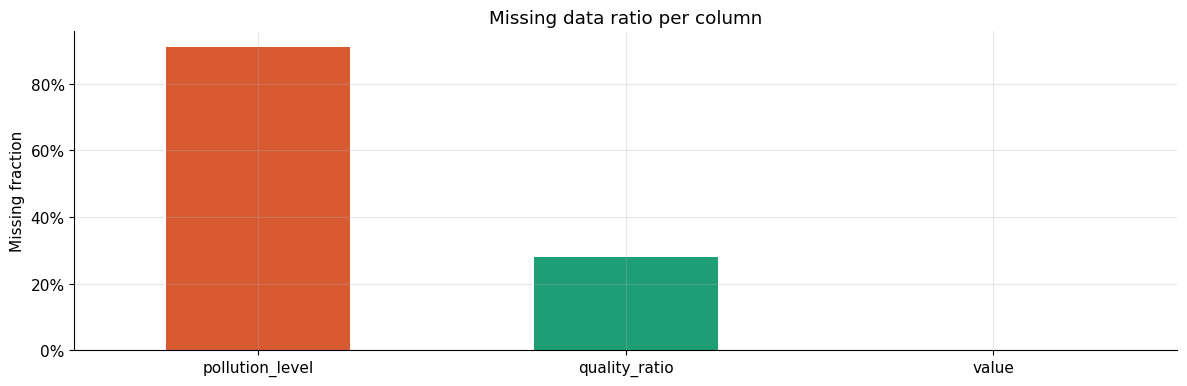

In [9]:
miss = df[["value", "quality_ratio", "pollution_level"]].isna().mean().sort_values(ascending=False)
print(miss.to_string())
 
fig, ax = plt.subplots()
miss.plot(kind="bar", ax=ax, color=["#D85A30", "#1D9E75", "#378ADD"])
ax.set_ylabel("Missing fraction")
ax.set_title("Missing data ratio per column")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 3.2 missingness over time (daily)

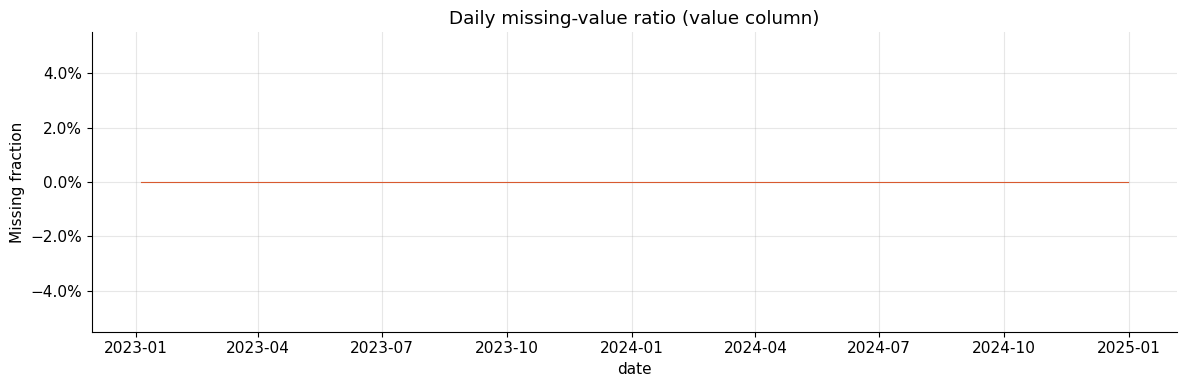

In [10]:
df["date"] = df["measurement_timestamp"].dt.date
miss_time = df.groupby("date")["value"].apply(lambda x: x.isna().mean())
 
fig, ax = plt.subplots()
miss_time.plot(ax=ax, color="#D85A30", linewidth=0.8)
ax.set_ylabel("Missing fraction")
ax.set_title("Daily missing-value ratio (value column)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

## 4 · Sampling regularity

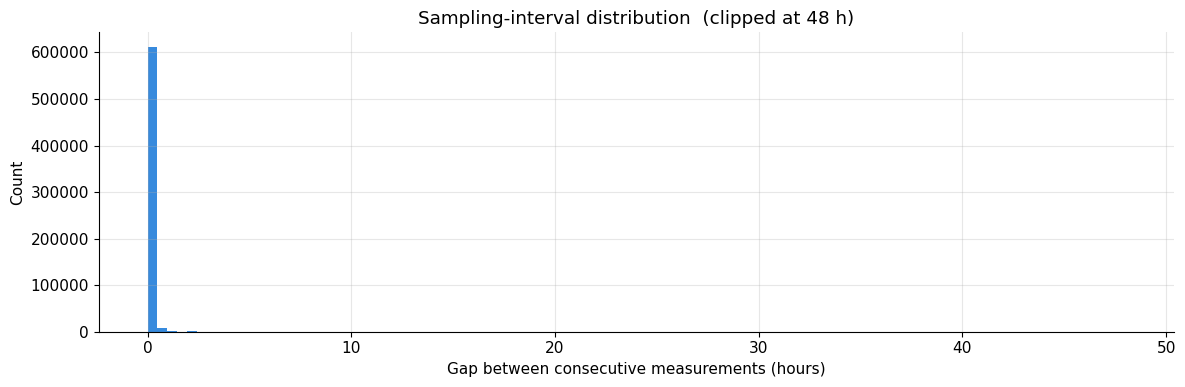

Dominant interval: 0.3 h


In [11]:
df_sorted = df.sort_values(["station_id", "parameter_code", "measurement_timestamp"])
df_sorted["delta_h"] = (
    df_sorted.groupby(["station_id", "parameter_code"])["measurement_timestamp"]
    .diff()
    .dt.total_seconds() / 3600
)
 
fig, ax = plt.subplots()
df_sorted["delta_h"].clip(upper=48).hist(bins=100, ax=ax, color="#378ADD", edgecolor="none")
ax.set_xlabel("Gap between consecutive measurements (hours)")
ax.set_ylabel("Count")
ax.set_title("Sampling-interval distribution  (clipped at 48 h)")
plt.tight_layout()
plt.show()
 
# dominant interval
dominant = df_sorted["delta_h"].dropna().round(1).mode()[0]
print(f"Dominant interval: {dominant} h")


## 5 · Value distributions

In [23]:
df.columns

Index(['measurement_id', 'measurement_timestamp', 'station_key',
       'parameter_key', 'value', 'quality_ratio', 'pollution_level',
       'offset_minutes', 'station_id', 'station_name', 'parameter_code',
       'parameter_name', 'date', 'hour', 'weekday', 'month'],
      dtype='str')

### 5.1 raw distribution

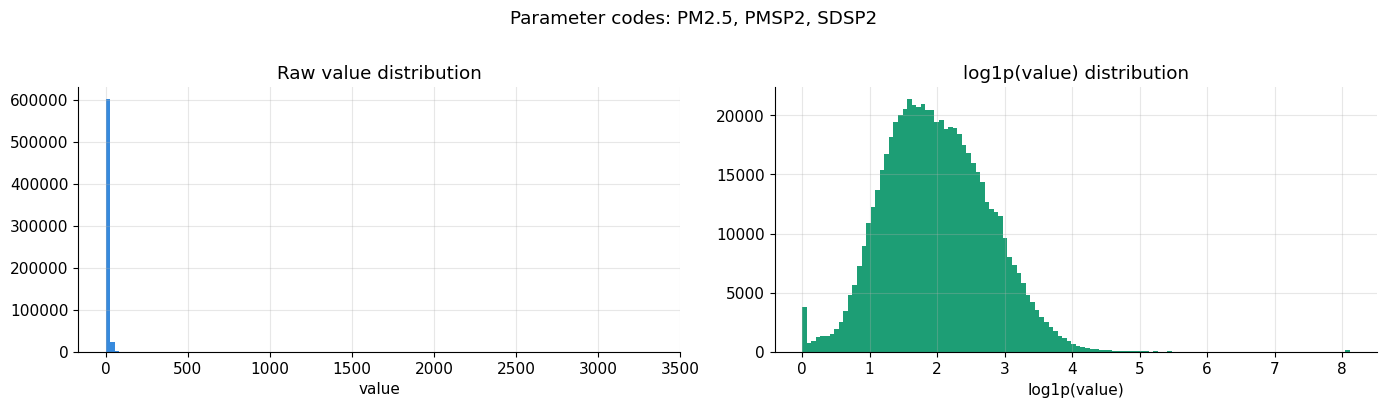

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
df["value"].hist(bins=120, ax=axes[0], color="#378ADD", edgecolor="none")
axes[0].set_title("Raw value distribution")
axes[0].set_xlabel("value")
 
np.log1p(df["value"].clip(lower=0)).hist(bins=120, ax=axes[1],
                                          color="#1D9E75", edgecolor="none")
axes[1].set_title("log1p(value) distribution")
axes[1].set_xlabel("log1p(value)")
 
plt.suptitle(f"Parameter codes: {', '.join(PARAM_CODES)}", y=1.01)
plt.tight_layout()
plt.show()


### 5.2 per-parameter boxplot 

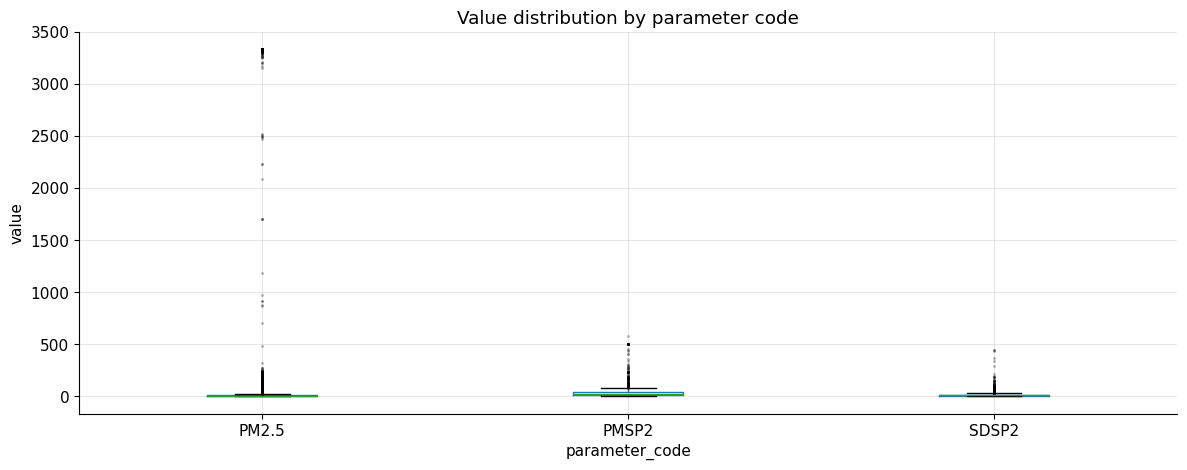

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
df.boxplot(column="value", by="parameter_code", ax=ax,
           flierprops=dict(marker=".", markersize=2, alpha=0.3))
ax.set_title("Value distribution by parameter code")
plt.suptitle("")
ax.set_xlabel("parameter_code")
ax.set_ylabel("value")
plt.tight_layout()
plt.show()

## 7 · Station-level variability

 station_id                                       station_name      mean        std  count  pct_missing
        271                                      vinnytsia-271 32.101196 238.727524  22142          0.0
       1315            Vinnytsia National Technical University 23.603941  10.918900  27993          0.0
         92                                       vinnytsia-92 15.177234  11.253481   2374          0.0
       1769                                            Lun-315 11.716782  10.360643  12095          0.0
        315                                      vinnytsia-315 11.323228   8.687411  34278          0.0
        774                                    Станція замостя 11.079827  10.012887  43623          0.0
        274                                      vinnytsia-274 10.701095   6.023066   5917          0.0
       1434                                            Lun-129 10.632057  10.919347   5776          0.0
        256                                      vinnytsia-256 1

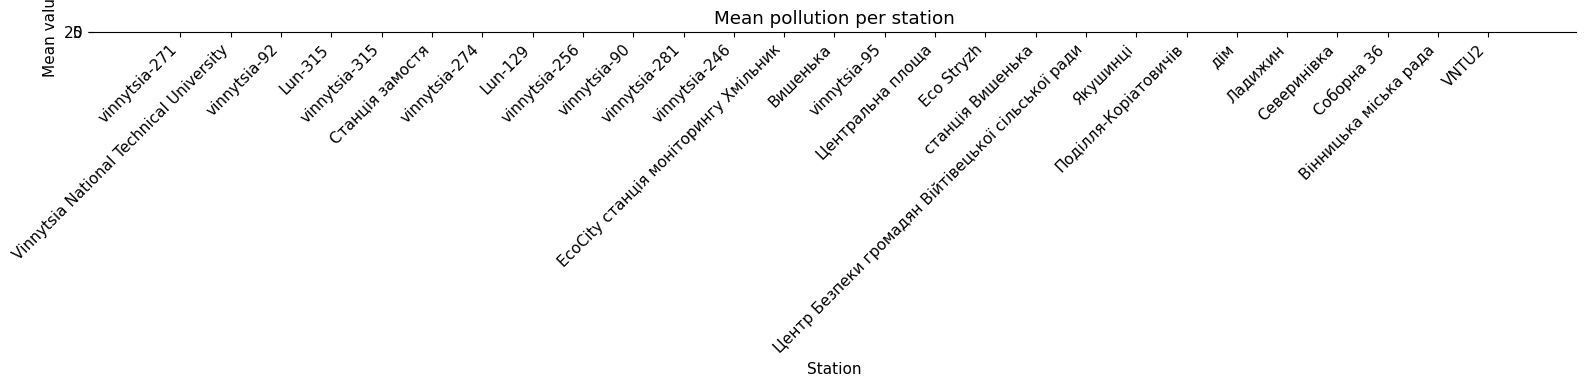

In [14]:
station_stats = (
    df.groupby(["station_id", "station_name"])["value"]
    .agg(mean="mean", std="std", count="count", pct_missing=lambda x: x.isna().mean())
    .reset_index()
    .sort_values("mean", ascending=False)
)
print(station_stats.to_string(index=False))
 
# %%
fig, ax = plt.subplots(figsize=(max(8, len(station_stats) * 0.6), 4))
ax.bar(station_stats["station_name"].astype(str),
       station_stats["mean"], color="#378ADD", alpha=0.85)
ax.set_xlabel("Station")
ax.set_ylabel("Mean value")
ax.set_title("Mean pollution per station")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 8 · Temporal patterns

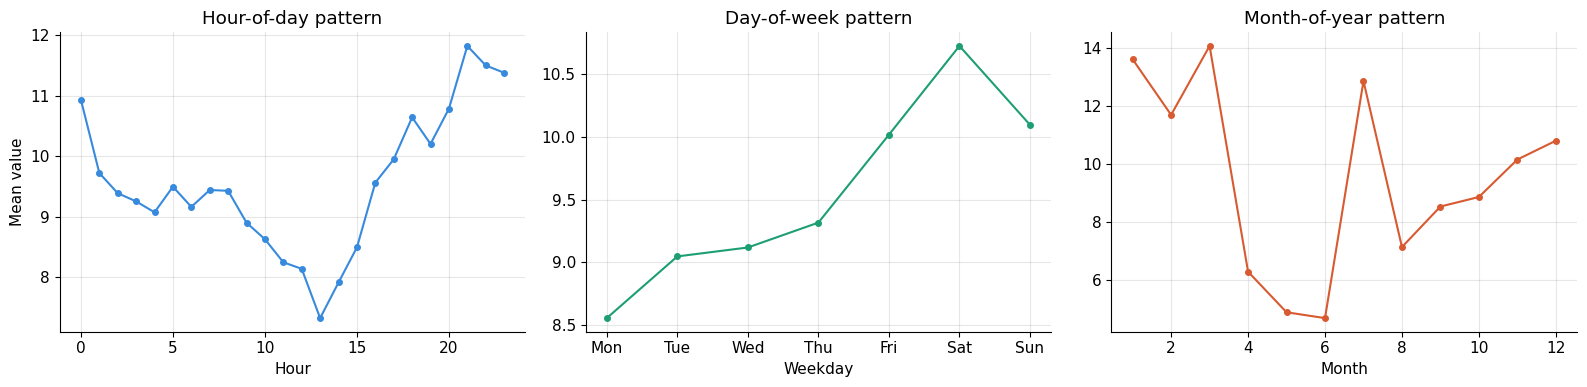

In [15]:
df["hour"]    = df["measurement_timestamp"].dt.hour
df["weekday"] = df["measurement_timestamp"].dt.dayofweek   # 0=Mon
df["month"]   = df["measurement_timestamp"].dt.month
 
WEEKDAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
df.groupby("hour")["value"].mean().plot(ax=axes[0], marker="o",
                                         color="#378ADD", markersize=4)
axes[0].set_title("Hour-of-day pattern")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Mean value")
 
weekday_mean = df.groupby("weekday")["value"].mean()
weekday_mean.index = WEEKDAY_LABELS
weekday_mean.plot(ax=axes[1], marker="o", color="#1D9E75", markersize=4)
axes[1].set_title("Day-of-week pattern")
axes[1].set_xlabel("Weekday")
 
df.groupby("month")["value"].mean().plot(ax=axes[2], marker="o",
                                          color="#D85A30", markersize=4)
axes[2].set_title("Month-of-year pattern")
axes[2].set_xlabel("Month")
 
plt.tight_layout()
plt.show()

## 9 · Quality ratio analysis

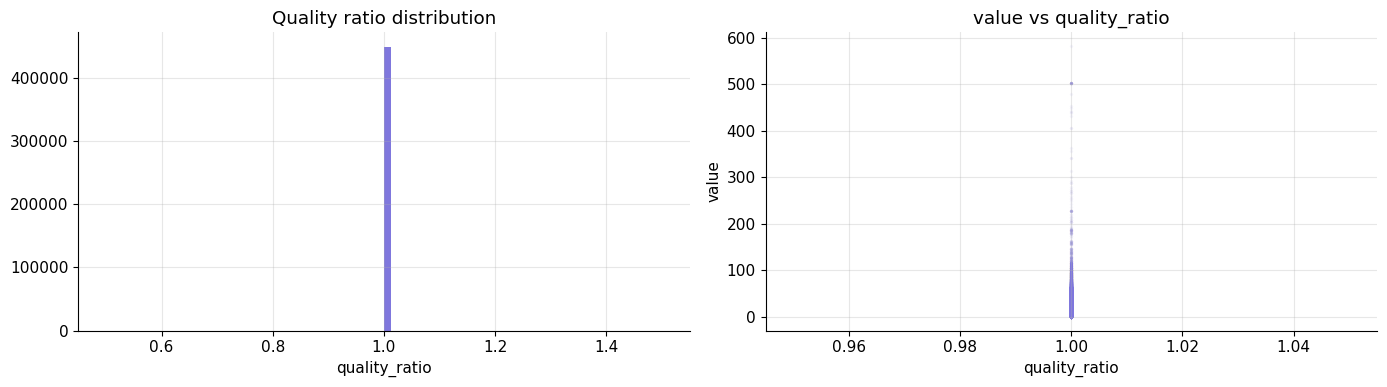

Pearson r(value, quality_ratio) = nan


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
df["quality_ratio"].hist(bins=80, ax=axes[0], color="#7F77DD", edgecolor="none")
axes[0].set_title("Quality ratio distribution")
axes[0].set_xlabel("quality_ratio")
 
axes[1].scatter(df["quality_ratio"], df["value"],
                alpha=0.05, s=2, color="#7F77DD")
axes[1].set_xlabel("quality_ratio")
axes[1].set_ylabel("value")
axes[1].set_title("value vs quality_ratio")
 
plt.tight_layout()
plt.show()
 
corr = df[["value", "quality_ratio"]].corr().iloc[0, 1]
print(f"Pearson r(value, quality_ratio) = {corr:.3f}")


## 10 · Pollution level audit

pollution_level distribution:
pollution_level
1    32461
2    14295
3     2758
4     4586
5      625


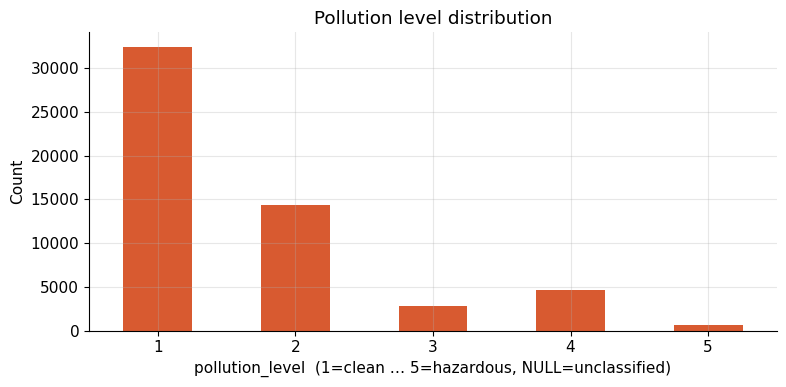

In [17]:
level_counts = df["pollution_level"].value_counts().sort_index()
print("pollution_level distribution:")
print(level_counts.to_string())
 
fig, ax = plt.subplots(figsize=(8, 4))
level_counts.plot(kind="bar", ax=ax, color="#D85A30", edgecolor="none")
ax.set_xlabel("pollution_level  (1=clean … 5=hazardous, NULL=unclassified)")
ax.set_ylabel("Count")
ax.set_title("Pollution level distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 11 · Pollutant correlation  (multi-parameter)
Expand `PARAM_CODES` in §2 to include all parameters, then re-run from §2.
This cell pivots the loaded slice.

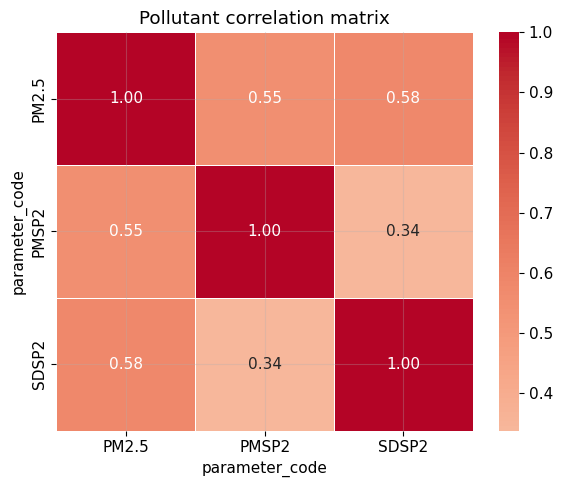

In [18]:
pivot = df.pivot_table(
    index="measurement_timestamp",
    columns="parameter_code",
    values="value",
    aggfunc="mean",
)
 
if pivot.shape[1] > 1:
    corr_matrix = pivot.corr()
    fig, ax = plt.subplots(figsize=(max(6, pivot.shape[1]), max(5, pivot.shape[1] - 1)))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, linewidths=0.5, ax=ax)
    ax.set_title("Pollutant correlation matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Only one parameter loaded — load multiple codes in §2 to see correlations.")


## 12 · SCD-2 history check
Verify that every SCD-2 chain is closed correctly: no gaps, no overlaps.

In [19]:
sql_scd = """
SELECT
    parameter_code,
    COUNT(*)                                          AS total_versions,
    SUM(CASE WHEN is_current = 1 THEN 1 ELSE 0 END)  AS current_count,
    MIN(valid_from)                                   AS earliest,
    MAX(valid_from)                                   AS latest_activation
FROM dim_parameters
GROUP BY parameter_code
HAVING current_count != 1
"""
df_scd_issues = pd.read_sql(sql_scd, engine)
if df_scd_issues.empty:
    print("✓ Every parameter_code has exactly one current version.")
else:
    print("⚠ Parameters with SCD-2 issues (current_count ≠ 1):")
    print(df_scd_issues.to_string(index=False))


✓ Every parameter_code has exactly one current version.


Same check for stations

In [20]:
sql_scd_st = """
SELECT
    station_id,
    COUNT(*)                                          AS total_versions,
    SUM(CASE WHEN is_current = 1 THEN 1 ELSE 0 END)  AS current_count
FROM dim_stations
GROUP BY station_id
HAVING current_count != 1
"""
df_scd_st = pd.read_sql(sql_scd_st, engine)
if df_scd_st.empty:
    print("✓ Every station_id has exactly one current version.")
else:
    print("⚠ Stations with SCD-2 issues:")
    print(df_scd_st.to_string(index=False))


✓ Every station_id has exactly one current version.


## 13 · Row counts and date coverage per station × parameter

In [21]:
sql_coverage = """
SELECT
    ds.station_id,
    ds.station_name,
    dp.parameter_code,
    COUNT(*)                         AS row_count,
    MIN(fm.measurement_timestamp)    AS first_ts,
    MAX(fm.measurement_timestamp)    AS last_ts,
    SUM(fm.value IS NULL)            AS null_values
FROM fact_measurements fm
JOIN dim_stations   ds ON fm.station_key   = ds.station_key  AND ds.is_current = 1
JOIN dim_parameters dp ON fm.parameter_key = dp.parameter_key AND dp.is_current = 1
GROUP BY ds.station_id, ds.station_name, dp.parameter_code
ORDER BY ds.station_id, dp.parameter_code
"""
df_coverage = pd.read_sql(sql_coverage, engine)
df_coverage["null_pct"] = (df_coverage["null_values"] / df_coverage["row_count"] * 100).round(1)
print(df_coverage.to_string(index=False))


 station_id                                       station_name    parameter_code  row_count            first_ts             last_ts  null_values  null_pct
         65                                       vinnytsia-65          Humidity       6800 2025-12-03 18:55:00 2026-04-26 21:34:00          0.0       0.0
         65                                       vinnytsia-65              PM10      13600 2025-12-03 18:55:00 2026-04-26 21:34:00          0.0       0.0
         65                                       vinnytsia-65             PM2.5       6800 2025-12-03 18:55:00 2026-04-26 21:34:00          0.0       0.0
         65                                       vinnytsia-65          Pressure       6800 2025-12-03 18:55:00 2026-04-26 21:34:00          0.0       0.0
         65                                       vinnytsia-65       Temperature       6800 2025-12-03 18:55:00 2026-04-26 21:34:00          0.0       0.0
         90                                       vinnytsia-90        